In [8]:
import os
import re
import unicodedata
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, jaccard_score, roc_auc_score, classification_report
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
warnings.filterwarnings('ignore')

In [9]:
DATASET_PATH = '../dataset'

# Load all 16 CSV files and combine them
frames = []
for filename in os.listdir(DATASET_PATH):
    if filename.endswith('.csv'):
        filepath = os.path.join(DATASET_PATH, filename)
        df_temp = pd.read_csv(filepath, usecols=['movie_id', 'movie_name', 'description', 'genre'])
        frames.append(df_temp)

df = pd.concat(frames, ignore_index=True)
print(f'Total rows after combining: {df.shape[0]}')

# Drop rows missing description or genre
df = df.dropna(subset=['description', 'genre'])

# Remove duplicate movies (same movie appeared in multiple genre files)
df = df.drop_duplicates(subset=['movie_id'])
df = df.reset_index(drop=True)

# Fill missing movie names
df['movie_name'] = df['movie_name'].fillna('Unknown')

# Keep only rows where description has at least 10 words
df = df[df['description'].str.split().str.len() >= 10].reset_index(drop=True)

# Parse the genre column into a list (e.g. 'Action, Adventure' -> ['Action', 'Adventure'])
df['genre'] = df['genre'].apply(lambda x: [g.strip() for g in x.split(',')] if isinstance(x, str) else [])

print(f'After cleaning: {df.shape[0]} movies')
df.head(3)

Total rows after combining: 368300
After cleaning: 181735 movies


,movie_id,movie_name,genre,description
0,tt9114286,Black Panther: Wakanda Forever,"[Action, Adventure, Drama]",The people of Wakanda fight to protect their h...
1,tt1630029,Avatar: The Way of Water,"[Action, Adventure, Fantasy]",Jake Sully lives with his newfound family form...
2,tt5884796,Plane,"[Action, Thriller]",A pilot finds himself caught in a war zone aft...


In [10]:
# Five simple preprocessing steps — each does one thing

def remove_accents(text):
    # Turn accented letters into plain ASCII (e.g. 'café' -> 'cafe')
    nfkd = unicodedata.normalize('NFD', text)
    return nfkd.encode('ascii', 'ignore').decode('utf-8')

def remove_punctuation(text):
    # Remove characters like ! ? " and replace , . ; ( ) etc. with spaces
    text = re.sub(r'[?!\'\"#]', '', text)
    text = re.sub(r'[,\.;:\(\)\{\}|/<>]|-', ' ', text)
    return text

def keep_alpha(text):
    # Remove anything that is not a letter or space
    return re.sub(r'[^a-zA-Z ]', ' ', text)

def lower_case(text):
    return text.lower()

def lemmatize_and_remove_stopwords(text):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    # Extra words that appear a lot in movie descriptions but carry no genre signal
    stop_words.update(['add', 'plot', 'summary', 'full', 'see', 'life',
                       'story', 'live', 'find', 'young', 'one', 'two',
                       'love', 'man', 'become'])
    tokens = []
    for word in text.split():
        if word not in stop_words and len(word) > 2:
            tokens.append(lemmatizer.lemmatize(word, 'v'))
    return ' '.join(tokens)

def text_preprocess(text):
    if not isinstance(text, str):
        return ''
    text = remove_accents(text)
    text = remove_punctuation(text)
    text = keep_alpha(text)
    text = lower_case(text)
    text = lemmatize_and_remove_stopwords(text)
    return text

print('Preprocessing descriptions...')
df['clean_description'] = df['description'].apply(text_preprocess)
print('Done.')
df[['description', 'clean_description']].head(2)

Preprocessing descriptions...
Done.


,description,clean_description
0,The people of Wakanda fight to protect their h...,people wakanda fight protect home intervene wo...
1,Jake Sully lives with his newfound family form...,jake sully live newfound family form extrasola...


In [11]:
MIN_GENRE_COUNT = 1000

# Count how many movies each genre appears in
genre_counts = {}
for genre_list in df['genre']:
    for genre in genre_list:
        if genre not in genre_counts:
            genre_counts[genre] = 0
        genre_counts[genre] += 1

genre_counts = pd.Series(genre_counts).sort_values(ascending=False)

# Keep only genres that appear in at least 1000 movies
GENRE_COLS = sorted([g for g, c in genre_counts.items() if c >= MIN_GENRE_COUNT])
print(f'Keeping {len(GENRE_COLS)} genres: {GENRE_COLS}')

# Remove genres from each movie's list that are not in the valid set
df['genre'] = df['genre'].apply(lambda gs: [g for g in gs if g in GENRE_COLS])

# Remove movies that have no valid genres left
df = df[df['genre'].apply(len) > 0].reset_index(drop=True)

# One-hot encode: one column per genre (1 = movie has that genre, 0 = does not)
for g in GENRE_COLS:
    df[g] = df['genre'].apply(lambda gs: 1 if g in gs else 0)

print(f'Final dataset: {df.shape[0]} movies, {len(GENRE_COLS)} genres')

Keeping 20 genres: ['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Sport', 'Thriller', 'War', 'Western']
Final dataset: 181735 movies, 20 genres


In [12]:
X = df[['clean_description']]
y = df[GENRE_COLS].astype(int)

# Use stratified k-fold so each fold has a similar genre distribution
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# We only need one fold — fold 0 gives us our train/test split
train_idx, test_idx = next(mskf.split(X, y))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

print(f'Train: {len(train_df):,}  |  Test: {len(test_df):,}')

Train: 145,430  |  Test: 36,305


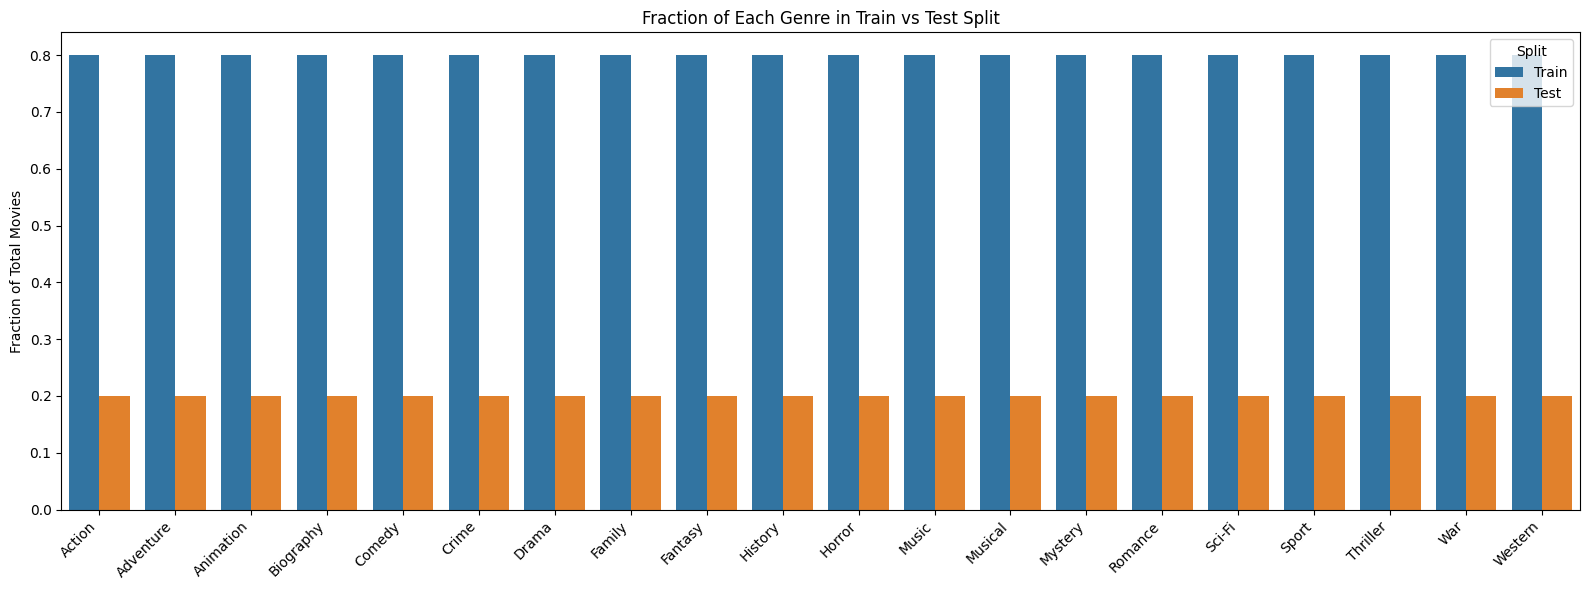

Train size: 145430 | Test size: 36305


In [13]:
# Verify the train/test split is balanced — each genre should have ~80% in train, ~20% in test
# If this plot looks uneven, the stratification did not work correctly

total_per_genre = df[GENRE_COLS].astype(int).sum()
train_per_genre = train_df[GENRE_COLS].astype(int).sum()
test_per_genre  = test_df[GENRE_COLS].astype(int).sum()

# Fraction of each genre that went to train and test
train_frac = train_per_genre / total_per_genre
test_frac  = test_per_genre  / total_per_genre

dist_df = pd.DataFrame({
    'Genre': GENRE_COLS * 2,
    'Fraction': list(train_frac) + list(test_frac),
    'Split': ['Train'] * len(GENRE_COLS) + ['Test'] * len(GENRE_COLS)
})

plt.figure(figsize=(16, 6))
sns.barplot(data=dist_df, x='Genre', y='Fraction', hue='Split')
plt.title('Fraction of Each Genre in Train vs Test Split')
plt.ylabel('Fraction of Total Movies')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Train size:', len(train_df), '| Test size:', len(test_df))

### Key Takeaway — Stratified Split

Each genre has roughly the same fraction in train and test (about 80/20). This confirms that `MultilabelStratifiedKFold` correctly preserved the label distribution — a random split would cause rare genres to be underrepresented in one split.

In [14]:
# Convert text to TF-IDF features
# max_features=15000 keeps the 15k most important words/bigrams
# ngram_range=(1,2) includes both single words and two-word phrases
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))

X_train = tfidf.fit_transform(train_df['clean_description'])
X_test  = tfidf.transform(test_df['clean_description'])

y_train = train_df[GENRE_COLS].astype(int)
y_test  = test_df[GENRE_COLS].astype(int)

print(f'TF-IDF train: {X_train.shape}  |  test: {X_test.shape}')

TF-IDF train: (145430, 15000)  |  test: (36305, 15000)


In [15]:
# OneVsRest trains one binary classifier per genre
# class_weight='balanced' helps with the imbalance (Drama >> Film-Noir)
lr = OneVsRestClassifier(
    LogisticRegression(C=1.0, class_weight='balanced',
                       solver='liblinear', max_iter=1000),
    n_jobs=-1
)

print('Training OneVsRest Logistic Regression...')
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print('Done.')

Training OneVsRest Logistic Regression...
Done.


In [16]:
micro_f1  = f1_score(y_test, y_pred, average='micro')
macro_f1  = f1_score(y_test, y_pred, average='macro')
jaccard   = jaccard_score(y_test, y_pred, average='micro')
roc_auc   = roc_auc_score(y_test, y_pred, average='micro')

print('=' * 45)
print(f'  Micro F1  : {micro_f1:.4f}')
print(f'  Macro F1  : {macro_f1:.4f}')
print(f'  Jaccard   : {jaccard:.4f}')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print('=' * 45)

  Micro F1  : 0.4709
  Macro F1  : 0.4032
  Jaccard   : 0.3079
  ROC-AUC   : 0.7717


In [17]:
# Per-genre breakdown — useful to spot which genres the model struggles with
report = classification_report(y_test, y_pred,
                                target_names=GENRE_COLS,
                                output_dict=True)
report_df = pd.DataFrame(report).T.loc[GENRE_COLS, ['precision', 'recall', 'f1-score', 'support']]
report_df = report_df.sort_values('f1-score', ascending=False).round(3)
print(report_df.to_string())

           precision  recall  f1-score  support
Horror         0.516   0.788     0.624   5719.0
Drama          0.568   0.664     0.612  14804.0
Romance        0.492   0.758     0.597   7128.0
Action         0.460   0.704     0.556   7571.0
Crime          0.415   0.708     0.524   5639.0
Comedy         0.399   0.675     0.501   7431.0
War            0.339   0.787     0.474   1184.0
Thriller       0.367   0.664     0.473   7040.0
Sport          0.333   0.784     0.468    597.0
Sci-Fi         0.319   0.726     0.444   2188.0
Adventure      0.278   0.653     0.390   3944.0
Family         0.228   0.685     0.342   2394.0
Biography      0.204   0.675     0.313   1275.0
History        0.195   0.696     0.305   1222.0
Fantasy        0.189   0.614     0.289   2288.0
Western        0.181   0.618     0.280    319.0
Mystery        0.179   0.570     0.272   2744.0
Animation      0.173   0.632     0.271   1251.0
Music          0.117   0.540     0.192    648.0
Musical        0.082   0.439     0.138  

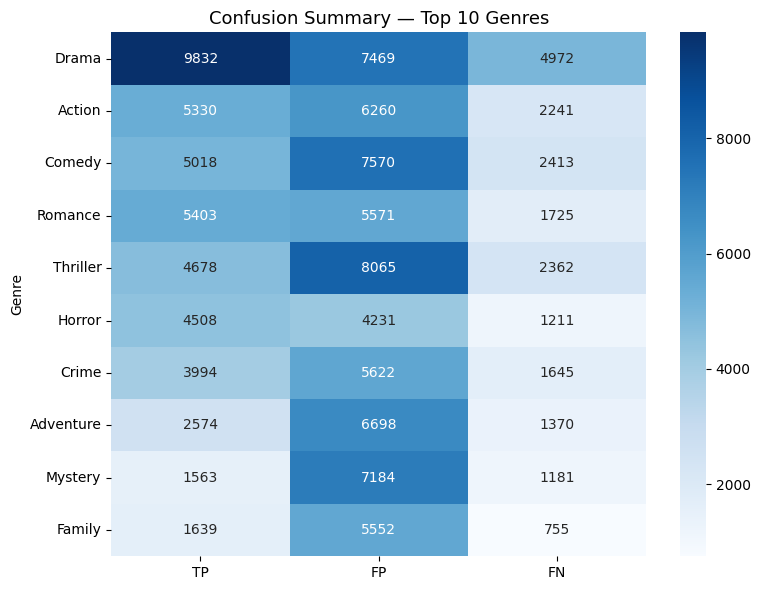

In [18]:
from sklearn.metrics import multilabel_confusion_matrix

# Take the 10 genres with the most movies
top10 = genre_counts[GENRE_COLS].nlargest(10).index.tolist()
top10_idx = [GENRE_COLS.index(g) for g in top10]

y_test_top = np.array(y_test)[:, top10_idx]
y_pred_top = y_pred[:, top10_idx]

mcm = multilabel_confusion_matrix(y_test_top, y_pred_top)

# Build a summary table: TP, FP, FN for each genre
rows = []
for i in range(len(top10)):
    rows.append({
        'Genre': top10[i],
        'TP': mcm[i][1, 1],
        'FP': mcm[i][0, 1],
        'FN': mcm[i][1, 0]
    })
summary = pd.DataFrame(rows).set_index('Genre')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(summary[['TP', 'FP', 'FN']], annot=True, fmt='d',
            cmap='Blues', ax=ax)
ax.set_title('Confusion Summary — Top 10 Genres', fontsize=13)
plt.tight_layout()
plt.show()

## Baseline Results Summary

| Model | Micro F1 | Macro F1 | Jaccard | ROC-AUC |
|---|---|---|---|---|
| TF-IDF + Logistic Regression | 0.4709 | 0.4032 | 0.3079 | 0.7717 |

This classical approach is fast and interpretable but struggles with:
- Rare genres (Musical, Animation) due to class imbalance
- Semantic understanding — a description can imply "Horror" without using the word

**Next step:** [03_llm_finetuning.ipynb](03_llm_finetuning.ipynb) — fine-tune transformer models to beat this baseline.